In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


In [32]:
columns = ['ID', 'Age', 'Sex','Monthly_Income (Million VND)', 'NumOfPurchase', 'ValuePerOrder (Million VND)']
data  = pd.DataFrame(columns= columns)

In [33]:
data.loc[len(data)] = ([1, 25, 'Male', 15000000, 5, 300000])
data.loc[len(data)] = ([2, 30, 'Female', 20000000, 3, 400000])
data.loc[len(data)] = ([3, 22, 'Male', 10000000, 7, 250000])
data.loc[len(data)] = ([4, 28, 'Female', 18000000, 4, 350000])
data.loc[len(data)] = ([5, 35, 'Male', 25000000, 2, 600000])
data.loc[len(data)] = ([6, 40, 'Female', 30000000, 3, 500000])
data.loc[len(data)] = ([7, 50, 'Male', 35000000, 1, 700000])
data.loc[len(data)] = ([8, 33, 'Female', 22000000, 6, 450000])
data.loc[len(data)] = ([9, 27, 'Male', 17000000, 4, 350000])
data.loc[len(data)] = ([10, 45, 'Female', 28000000, 2, 550000])



In [34]:
data['Monthly_Income (Million VND)'] = data['Monthly_Income (Million VND)'] / 1000000
data['ValuePerOrder (Million VND)'] = data['ValuePerOrder (Million VND)'] / 1000000
data

,ID,Age,Sex,Monthly_Income (Million VND),NumOfPurchase,ValuePerOrder (Million VND)
0,1,25,Male,15.0,5,0.30
1,2,30,Female,20.0,3,0.40
2,3,22,Male,10.0,7,0.25
3,4,28,Female,18.0,4,0.35
4,5,35,Male,25.0,2,0.60
5,6,40,Female,30.0,3,0.50
6,7,50,Male,35.0,1,0.70
7,8,33,Female,22.0,6,0.45
8,9,27,Male,17.0,4,0.35
9,10,45,Female,28.0,2,0.55


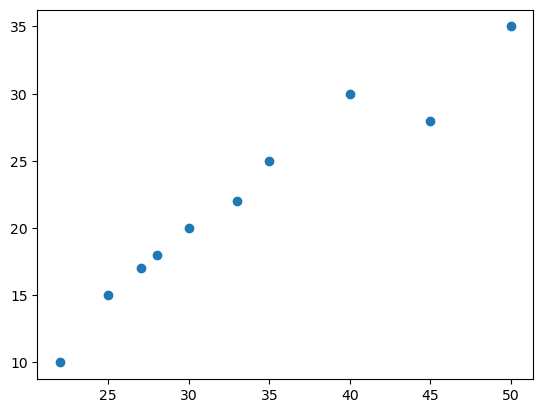

In [35]:
plt.scatter(x = data['Age'], y = data['Monthly_Income (Million VND)'])

# Câu 1 : Nhận diện nhóm khách hàng có thu nhập cao

- Nhóm thu nhập thấp : Dưới 8 triệu đồng / tháng
- Nhóm thu nhập trung bình thấp : 8 - 15 triệu đồng / tháng
- Nhóm thu nhập trung bình cao : 15 - 25 triệu / tháng
- Nhóm thu nhập cao : 25 - 50 triệu đồng / tháng


# Câu 2 : Phân tích sự phân bố độ tuổi và sự khác biệt trong hành vi mua sắm giữa các nhóm tuổi

In [36]:
data['Total_order_value (Million VND)'] = data['NumOfPurchase'] * data['ValuePerOrder (Million VND)']

In [37]:
data

,ID,Age,Sex,Monthly_Income (Million VND),NumOfPurchase,ValuePerOrder (Million VND),Total_order_value (Million VND)
0,1,25,Male,15.0,5,0.30,1.50
1,2,30,Female,20.0,3,0.40,1.20
2,3,22,Male,10.0,7,0.25,1.75
3,4,28,Female,18.0,4,0.35,1.40
4,5,35,Male,25.0,2,0.60,1.20
5,6,40,Female,30.0,3,0.50,1.50
6,7,50,Male,35.0,1,0.70,0.70
7,8,33,Female,22.0,6,0.45,2.70
8,9,27,Male,17.0,4,0.35,1.40
9,10,45,Female,28.0,2,0.55,1.10


## Phân bố độ tuổi
- Thanh thiếu niên : Dưới 20 tuổi
- Thanh niên : 20 - 29 tuổi
- Trung niên : 30 - 39 tuổi
- Cận cao tuổi 40 - 49 tuổi
- Cao tuổi : Trên 50 tuổi

In [38]:
def age_group(age):
    if age < 20:
        return "Thanh thiếu niên"
    elif 20 <= age < 30:
        return "Thanh niên"
    elif 30 <= age < 40:
        return "Trung niên"
    elif 40 <= age < 50:
        return "Cận cao tuổi"
    else:
        return "Cao tuổi"

data["Age Group"] = data["Age"].apply(age_group)

In [39]:
data

,ID,Age,Sex,Monthly_Income (Million VND),NumOfPurchase,ValuePerOrder (Million VND),Total_order_value (Million VND),Age Group
0,1,25,Male,15.0,5,0.30,1.50,Thanh niên
1,2,30,Female,20.0,3,0.40,1.20,Trung niên
2,3,22,Male,10.0,7,0.25,1.75,Thanh niên
3,4,28,Female,18.0,4,0.35,1.40,Thanh niên
4,5,35,Male,25.0,2,0.60,1.20,Trung niên
5,6,40,Female,30.0,3,0.50,1.50,Cận cao tuổi
6,7,50,Male,35.0,1,0.70,0.70,Cao tuổi
7,8,33,Female,22.0,6,0.45,2.70,Trung niên
8,9,27,Male,17.0,4,0.35,1.40,Thanh niên
9,10,45,Female,28.0,2,0.55,1.10,Cận cao tuổi


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6600\3648972219.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data = data, x = 'Age Group', palette = 'Set3');


Text(0.5, 1.0, 'Phân bố độ tuổi')

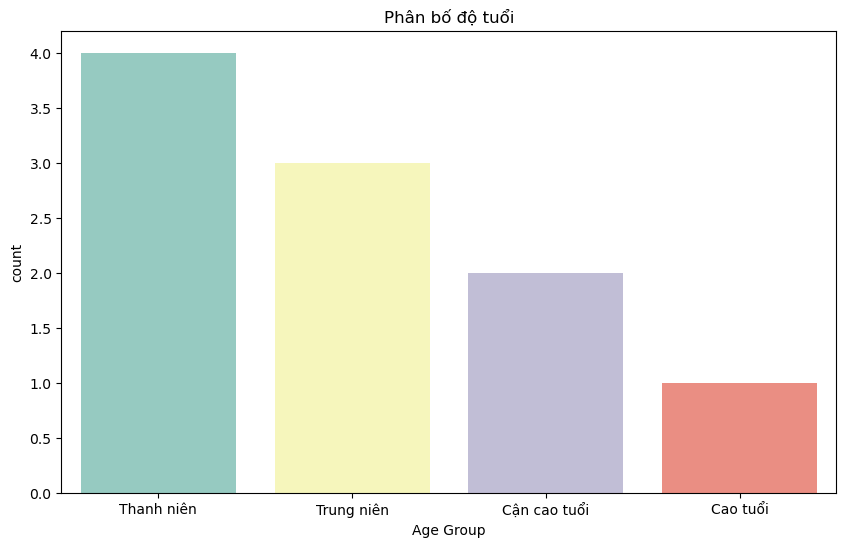

In [40]:
plt.figure(figsize = (10, 6))
sns.countplot(data = data, x = 'Age Group', palette = 'Set3');
plt.title("Phân bố độ tuổi")

## Sự khác biệt trong hành vi mua sắm giữa các nhóm tuổi

- Nhóm trung niên (30-39 tuổi) có tổng giá trị đơn hàng trung bình cao nhất.
- Nhóm thanh niên (20-29 tuổi) và cận cao tuổi (40-49 tuổi) có mức mua sắm khá tương đồng.
- Nhóm cao tuổi (50+) có mức chi tiêu thấp nhất.

In [41]:
# Xem số lượng khách hàng trong mỗi nhóm
print(data['Age Group'].value_counts())

# Tính toán tổng giá trị đơn hàng trung bình theo nhóm tuổi
age_group_mean = data.groupby('Age Group')['Total_order_value (Million VND)'].mean()
print(age_group_mean)

Age Group
Thanh niên      4
Trung niên      3
Cận cao tuổi    2
Cao tuổi        1
Name: count, dtype: int64
Age Group
Cao tuổi        0.7000
Cận cao tuổi    1.3000
Thanh niên      1.5125
Trung niên      1.7000
Name: Total_order_value (Million VND), dtype: float64


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_6600\254721941.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=data, x='Age Group', y='Total_order_value (Million VND)', palette='viridis')


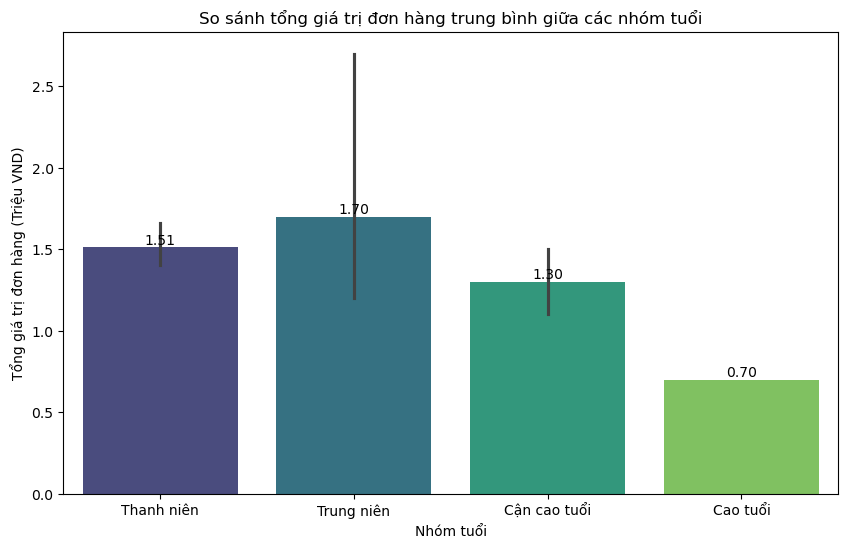

In [42]:
plt.figure(figsize=(10,6))
ax = sns.barplot(data=data, x='Age Group', y='Total_order_value (Million VND)', palette='viridis')
plt.title("So sánh tổng giá trị đơn hàng trung bình giữa các nhóm tuổi")
plt.xlabel("Nhóm tuổi")
plt.ylabel("Tổng giá trị đơn hàng (Triệu VND)")

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=10, color='black')

plt.show()

In [43]:
data

,ID,Age,Sex,Monthly_Income (Million VND),NumOfPurchase,ValuePerOrder (Million VND),Total_order_value (Million VND),Age Group
0,1,25,Male,15.0,5,0.30,1.50,Thanh niên
1,2,30,Female,20.0,3,0.40,1.20,Trung niên
2,3,22,Male,10.0,7,0.25,1.75,Thanh niên
3,4,28,Female,18.0,4,0.35,1.40,Thanh niên
4,5,35,Male,25.0,2,0.60,1.20,Trung niên
5,6,40,Female,30.0,3,0.50,1.50,Cận cao tuổi
6,7,50,Male,35.0,1,0.70,0.70,Cao tuổi
7,8,33,Female,22.0,6,0.45,2.70,Trung niên
8,9,27,Male,17.0,4,0.35,1.40,Thanh niên
9,10,45,Female,28.0,2,0.55,1.10,Cận cao tuổi


In [44]:
cor_columns = ['Age', 'Monthly_Income (Million VND)', 'NumOfPurchase', 'ValuePerOrder (Million VND)', 'Total_order_value (Million VND)']

In [45]:
data[cor_columns].corr()

,Age,Monthly_Income (Million VND),NumOfPurchase,ValuePerOrder (Million VND),Total_order_value (Million VND)
Age,1.000000,0.970346,-0.795625,0.928770,-0.455781
Monthly_Income (Million VND),0.970346,1.000000,-0.823623,0.943545,-0.425572
NumOfPurchase,-0.795625,-0.823623,1.000000,-0.833084,0.795319
ValuePerOrder (Million VND),0.928770,0.943545,-0.833084,1.000000,-0.451029
Total_order_value (Million VND),-0.455781,-0.425572,0.795319,-0.451029,1.000000


<Axes: >

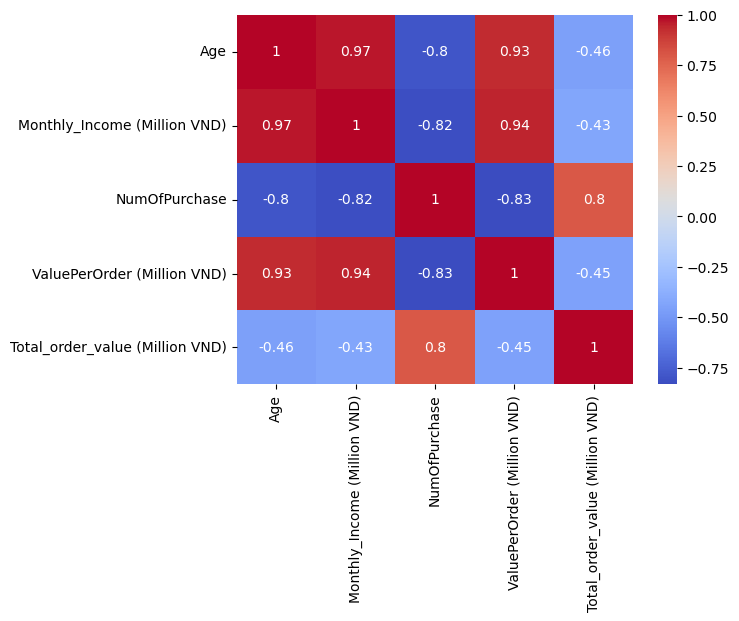

In [46]:
sns.heatmap(data[cor_columns].corr(), annot=True, cmap='coolwarm')

In [47]:
data

,ID,Age,Sex,Monthly_Income (Million VND),NumOfPurchase,ValuePerOrder (Million VND),Total_order_value (Million VND),Age Group
0,1,25,Male,15.0,5,0.30,1.50,Thanh niên
1,2,30,Female,20.0,3,0.40,1.20,Trung niên
2,3,22,Male,10.0,7,0.25,1.75,Thanh niên
3,4,28,Female,18.0,4,0.35,1.40,Thanh niên
4,5,35,Male,25.0,2,0.60,1.20,Trung niên
5,6,40,Female,30.0,3,0.50,1.50,Cận cao tuổi
6,7,50,Male,35.0,1,0.70,0.70,Cao tuổi
7,8,33,Female,22.0,6,0.45,2.70,Trung niên
8,9,27,Male,17.0,4,0.35,1.40,Thanh niên
9,10,45,Female,28.0,2,0.55,1.10,Cận cao tuổi


# Model 1

c:\Users\ADMIN\anaconda3\envs\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

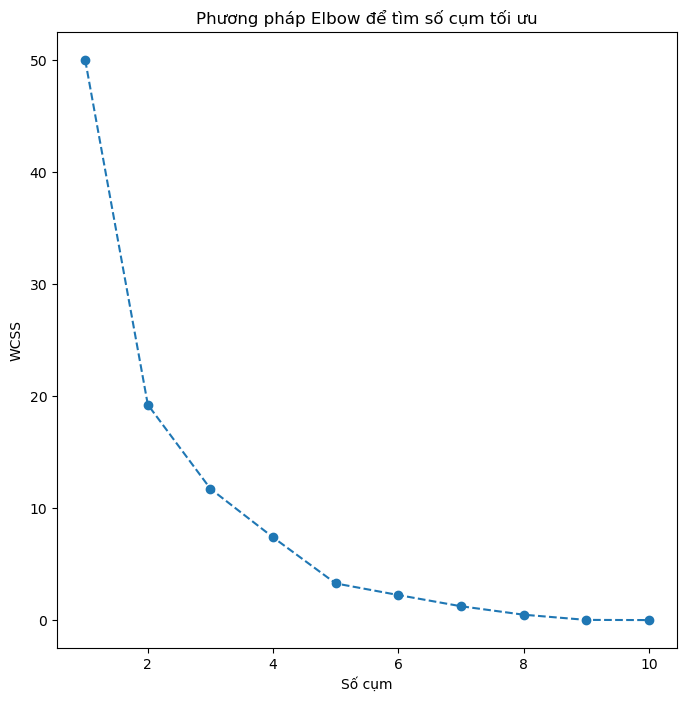

In [48]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data1 = data.copy()

# Đọc dữ liệu (nếu cần)
# data = pd.read_csv("duong_dan_file.csv")

# Chọn các cột để phân cụm
features = ['Age', 'Monthly_Income (Million VND)', 'NumOfPurchase',
            'ValuePerOrder (Million VND)', 'Total_order_value (Million VND)']

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data1[features])

# Tìm số cụm tối ưu bằng Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(data_scaled)
    wcss.append(kmeans.inertia_)
# Vẽ biểu đồ Elbow
plt.figure(figsize=(8,8))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.xlabel('Số cụm')
plt.ylabel('WCSS')
plt.title('Phương pháp Elbow để tìm số cụm tối ưu')
plt.show()





c:\Users\ADMIN\anaconda3\envs\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


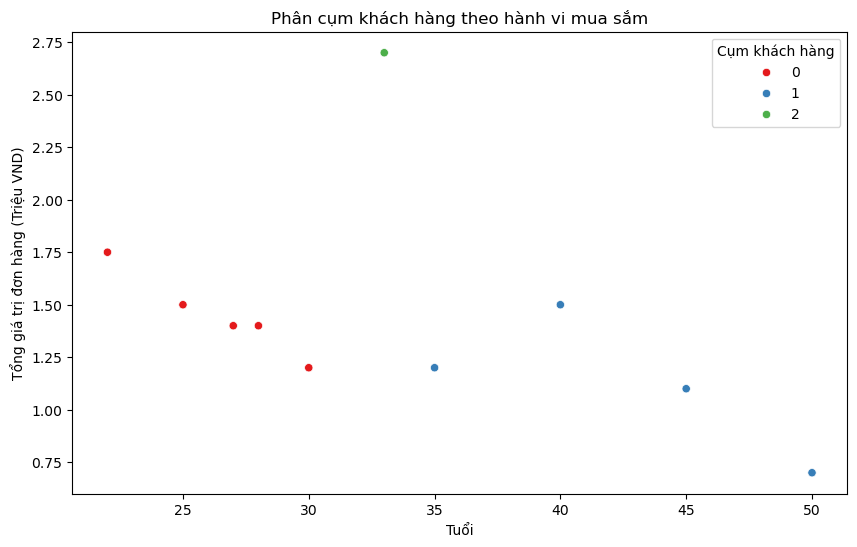

   Age  Monthly_Income (Million VND)  NumOfPurchase  Cluster
0   25                          15.0              5        0
1   30                          20.0              3        0
2   22                          10.0              7        0
3   28                          18.0              4        0
4   35                          25.0              2        1
5   40                          30.0              3        1
6   50                          35.0              1        1
7   33                          22.0              6        2
8   27                          17.0              4        0
9   45                          28.0              2        1


In [49]:

# Áp dụng K-Means với số cụm tối ưu (ví dụ chọn k=4)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
data1['Cluster'] = kmeans.fit_predict(data_scaled)

# Trực quan hóa cụm bằng scatter plot (dùng 2 biến chính)
plt.figure(figsize=(10,6))
sns.scatterplot(x=data1['Age'], y=data1['Total_order_value (Million VND)'], hue=data1['Cluster'], palette='Set1')
plt.xlabel("Tuổi")
plt.ylabel("Tổng giá trị đơn hàng (Triệu VND)")
plt.title("Phân cụm khách hàng theo hành vi mua sắm")
plt.legend(title="Cụm khách hàng")
plt.show()

# Xem kết quả phân cụm
print(data1[['Age', 'Monthly_Income (Million VND)', 'NumOfPurchase', 'Cluster']].head(10))

In [50]:
data1

,ID,Age,Sex,Monthly_Income (Million VND),NumOfPurchase,ValuePerOrder (Million VND),Total_order_value (Million VND),Age Group,Cluster
0,1,25,Male,15.0,5,0.30,1.50,Thanh niên,0
1,2,30,Female,20.0,3,0.40,1.20,Trung niên,0
2,3,22,Male,10.0,7,0.25,1.75,Thanh niên,0
3,4,28,Female,18.0,4,0.35,1.40,Thanh niên,0
4,5,35,Male,25.0,2,0.60,1.20,Trung niên,1
5,6,40,Female,30.0,3,0.50,1.50,Cận cao tuổi,1
6,7,50,Male,35.0,1,0.70,0.70,Cao tuổi,1
7,8,33,Female,22.0,6,0.45,2.70,Trung niên,2
8,9,27,Male,17.0,4,0.35,1.40,Thanh niên,0
9,10,45,Female,28.0,2,0.55,1.10,Cận cao tuổi,1


# Model

In [61]:
# Encode Sex
label = {
    'Male' : 1,
    'Female' : 2
}
data['Sex'] = data['Sex'].map(label)

In [62]:
features = ['Age', 'Monthly_Income (Million VND)', 'NumOfPurchase',
            'ValuePerOrder (Million VND)', 'Total_order_value (Million VND)']
se = StandardScaler()
data_scaled = se.fit_transform(data[features])

In [63]:
data

,ID,Age,Sex,Monthly_Income (Million VND),NumOfPurchase,ValuePerOrder (Million VND),Total_order_value (Million VND),Age Group,Cluster
0,1,25,NaN,15.0,5,0.30,1.50,Thanh niên,0
1,2,30,NaN,20.0,3,0.40,1.20,Trung niên,0
2,3,22,NaN,10.0,7,0.25,1.75,Thanh niên,2
3,4,28,NaN,18.0,4,0.35,1.40,Thanh niên,0
4,5,35,NaN,25.0,2,0.60,1.20,Trung niên,1
5,6,40,NaN,30.0,3,0.50,1.50,Cận cao tuổi,1
6,7,50,NaN,35.0,1,0.70,0.70,Cao tuổi,1
7,8,33,NaN,22.0,6,0.45,2.70,Trung niên,3
8,9,27,NaN,17.0,4,0.35,1.40,Thanh niên,0
9,10,45,NaN,28.0,2,0.55,1.10,Cận cao tuổi,1


In [64]:
k_rng = range(1, 11)
sse = []
for k in k_rng:
  km = KMeans(n_clusters=k, random_state=42, n_init=10)
  km.fit(data_scaled)
  sse.append(km.inertia_)






c:\Users\ADMIN\anaconda3\envs\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\ADMIN\anaconda3\envs\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

In [65]:
col = ['Number of K', 'SSE']
data_k = pd.DataFrame(columns=col)
for i in range(len(sse)):
  data_k.loc[len(data_k)] = [i + 1, sse[i]]

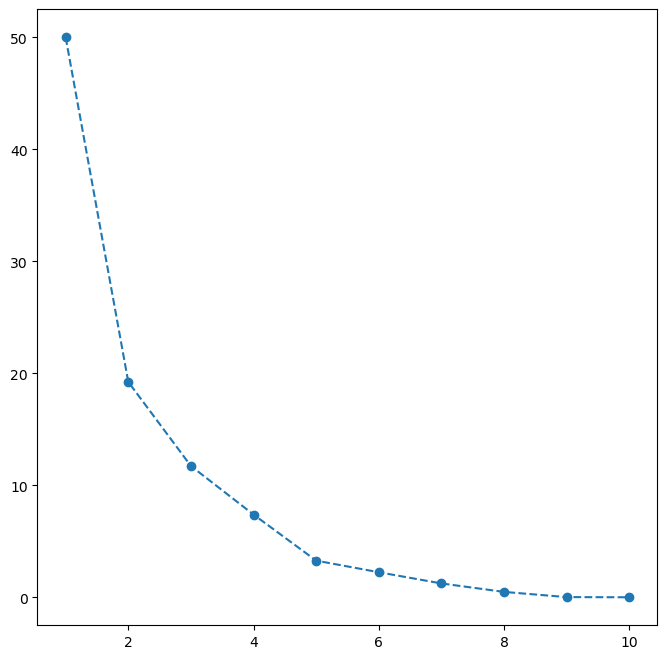

In [66]:
plt.figure(figsize = (8,8))
plt.plot(data_k['Number of K'], data_k['SSE'], marker = 'o', linestyle = '--')

Nếu muốn số cụm nhỏ và tổng quát hơn, chọn k  = 3

Nếu muốn phân nhóm chi tiết hơn, chọn k=4.

In [67]:
data

,ID,Age,Sex,Monthly_Income (Million VND),NumOfPurchase,ValuePerOrder (Million VND),Total_order_value (Million VND),Age Group,Cluster
0,1,25,NaN,15.0,5,0.30,1.50,Thanh niên,0
1,2,30,NaN,20.0,3,0.40,1.20,Trung niên,0
2,3,22,NaN,10.0,7,0.25,1.75,Thanh niên,2
3,4,28,NaN,18.0,4,0.35,1.40,Thanh niên,0
4,5,35,NaN,25.0,2,0.60,1.20,Trung niên,1
5,6,40,NaN,30.0,3,0.50,1.50,Cận cao tuổi,1
6,7,50,NaN,35.0,1,0.70,0.70,Cao tuổi,1
7,8,33,NaN,22.0,6,0.45,2.70,Trung niên,3
8,9,27,NaN,17.0,4,0.35,1.40,Thanh niên,0
9,10,45,NaN,28.0,2,0.55,1.10,Cận cao tuổi,1


In [68]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
y_pred = km.fit_predict(data_scaled)
data['Cluster'] = y_pred

c:\Users\ADMIN\anaconda3\envs\my_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [69]:
data

,ID,Age,Sex,Monthly_Income (Million VND),NumOfPurchase,ValuePerOrder (Million VND),Total_order_value (Million VND),Age Group,Cluster
0,1,25,NaN,15.0,5,0.30,1.50,Thanh niên,0
1,2,30,NaN,20.0,3,0.40,1.20,Trung niên,0
2,3,22,NaN,10.0,7,0.25,1.75,Thanh niên,2
3,4,28,NaN,18.0,4,0.35,1.40,Thanh niên,0
4,5,35,NaN,25.0,2,0.60,1.20,Trung niên,1
5,6,40,NaN,30.0,3,0.50,1.50,Cận cao tuổi,1
6,7,50,NaN,35.0,1,0.70,0.70,Cao tuổi,1
7,8,33,NaN,22.0,6,0.45,2.70,Trung niên,3
8,9,27,NaN,17.0,4,0.35,1.40,Thanh niên,0
9,10,45,NaN,28.0,2,0.55,1.10,Cận cao tuổi,1


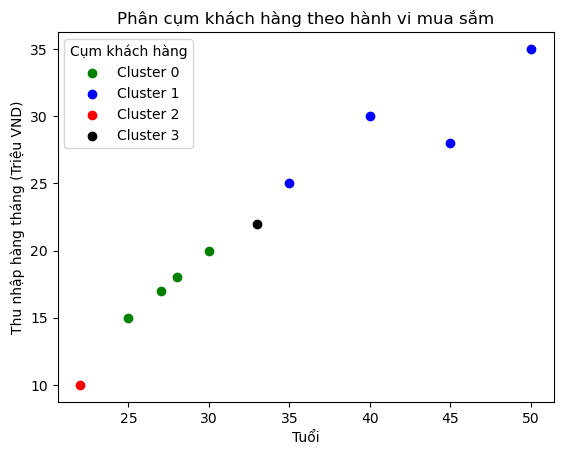

In [70]:
df1 = data[data['Cluster'] == 0]
df2 = data[data['Cluster'] == 1]
df3 = data[data['Cluster'] == 2]
df4 = data[data['Cluster'] == 3]


plt.scatter(x = df1['Age'], y = df1['Monthly_Income (Million VND)'], color = 'green', label = 'Cluster 0')
plt.scatter(x = df2['Age'], y = df2['Monthly_Income (Million VND)'], color = "blue", label = 'Cluster 1')
plt.scatter(x = df3['Age'], y = df3['Monthly_Income (Million VND)'], color = "red", label = 'Cluster 2')
plt.scatter(x = df4['Age'], y = df4['Monthly_Income (Million VND)'], color = 'black', label = 'Cluster 3')





plt.xlabel("Tuổi")
plt.ylabel("Thu nhập hàng tháng (Triệu VND)")
plt.title("Phân cụm khách hàng theo hành vi mua sắm")
plt.legend(title="Cụm khách hàng")
plt.legend(title="Cụm khách hàng")




